This file will process the raw fixations file that pop out of pupil neon; specifically, comparing the hill vs. the stair fixation data.

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
stair_path = "/Users/trentonwirth/Desktop/stair-hill_experiment/s2/s2_stair-condition-2025-11-13_03-24-05-4dcbe539/neon_player/exports/000_s2_stair-condition/fixations.csv"
hill_path = "/Users/trentonwirth/Desktop/stair-hill_experiment/s2/s2_hill-condition_2025-11-13_03-57-47-e10913da/neon_player/exports/000_s2_hill-condition/fixations.csv"

stair_fixations_df = pd.read_csv(stair_path)
hill_fixations_df = pd.read_csv(hill_path)


In [60]:
# remove fixations with duration > 1250 ms from both dataframes
stair_fixations_df = stair_fixations_df[stair_fixations_df["duration [ms]"] <= 1250].reset_index(drop=True)
hill_fixations_df  = hill_fixations_df[hill_fixations_df["duration [ms]"]  <= 1250].reset_index(drop=True)

print("Stair fixations kept:", len(stair_fixations_df))
print("Hill fixations kept: ", len(hill_fixations_df))

Stair fixations kept: 1765
Hill fixations kept:  1377


In [61]:
def generate_side_by_side_histogram(
    df_left: pd.DataFrame,
    df_right: pd.DataFrame,
    labels=("Left", "Right"),
    bins: int = 30,
    xlim: float = None,
    ylim: float = None,
    title_string: str = "Fixation Duration Comparison",
):

    # Create side-by-side axes
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Left histogram
    hist_left = axes[0].hist(
        df_left["duration [ms]"],
        bins=bins,
        edgecolor="black"
    )
    axes[0].set_title(f"{labels[0]} - {title_string}")
    axes[0].set_xlabel("Fixation Duration (ms)")
    axes[0].set_ylabel("Frequency")

    # Right histogram
    hist_right = axes[1].hist(
        df_right["duration [ms]"],
        bins=bins,
        edgecolor="black"
    )
    axes[1].set_title(f"{labels[1]} - {title_string}")
    axes[1].set_xlabel("Fixation Duration (ms)")

    # ---- Apply axis limits if provided ----
    if xlim is not None:
        axes[0].set_xlim(xlim)
        axes[1].set_xlim(xlim)

    if ylim is not None:
        axes[0].set_ylim(ylim)
        axes[1].set_ylim(ylim)

    plt.tight_layout()
    plt.show()

    # Summary statistics for each dataframe
    def summary(df):
        mean_duration = df["duration [ms]"].mean()
        sd_duration = df["duration [ms]"].std()
        n_fixations = len(df)
        total = df["duration [ms]"].sum()
        return {"mean": mean_duration, "sd": sd_duration, "n": n_fixations, "sum": total}

    stats_left = summary(df_left)
    stats_right = summary(df_right)

    print(f"{labels[0]} - Mean: {stats_left['mean']:.2f}, SD: {stats_left['sd']:.2f}, N: {stats_left['n']}, Sum: {stats_left['sum']:.0f}")
    print(f"{labels[1]} - Mean: {stats_right['mean']:.2f}, SD: {stats_right['sd']:.2f}, N: {stats_right['n']}, Sum: {stats_right['sum']:.0f}")

    return (hist_left, hist_right), (stats_left, stats_right)

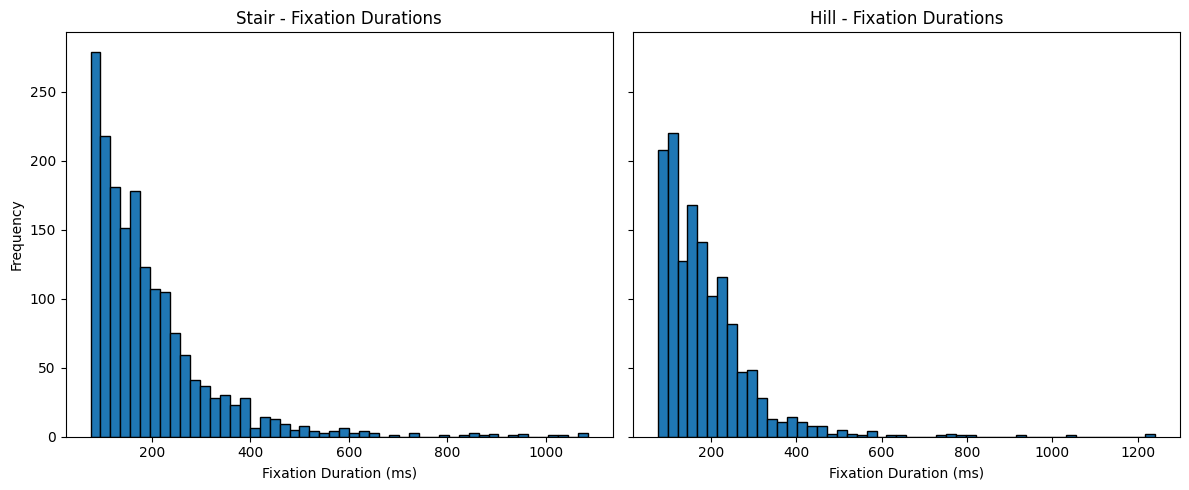

Stair - Mean: 196.39, SD: 127.77, N: 1765, Sum: 346637
Hill - Mean: 185.63, SD: 108.29, N: 1377, Sum: 255618


(((array([279., 218., 181., 151., 178., 123., 107., 105.,  75.,  59.,  41.,
           37.,  28.,  30.,  23.,  28.,   6.,  14.,  13.,   9.,   5.,   8.,
            4.,   3.,   4.,   6.,   3.,   4.,   3.,   0.,   1.,   0.,   3.,
            0.,   0.,   1.,   0.,   1.,   3.,   1.,   2.,   0.,   1.,   2.,
            0.,   0.,   1.,   1.,   0.,   3.]),
   array([  75.     ,   95.21994,  115.43988,  135.65982,  155.87976,
           176.0997 ,  196.31964,  216.53958,  236.75952,  256.97946,
           277.1994 ,  297.41934,  317.63928,  337.85922,  358.07916,
           378.2991 ,  398.51904,  418.73898,  438.95892,  459.17886,
           479.3988 ,  499.61874,  519.83868,  540.05862,  560.27856,
           580.4985 ,  600.71844,  620.93838,  641.15832,  661.37826,
           681.5982 ,  701.81814,  722.03808,  742.25802,  762.47796,
           782.6979 ,  802.91784,  823.13778,  843.35772,  863.57766,
           883.7976 ,  904.01754,  924.23748,  944.45742,  964.67736,
           984.897

In [62]:
# Side-by-side comparison: Stair vs Hill
generate_side_by_side_histogram(
    df_left=stair_fixations_df,
    df_right=hill_fixations_df,
    labels=("Stair", "Hill"),
    bins=50,
    title_string="Fixation Durations",
)


In [63]:
def compute_collection_duration(df, start_col='start timestamp [ns]', end_col='end timestamp [ns]'):
    """Return collection duration using the earliest start and latest end timestamps."""
    # Coerce to numeric (ns)
    start_vals = pd.to_numeric(df[start_col], errors='coerce')
    end_vals = pd.to_numeric(df[end_col], errors='coerce')

    first_start = start_vals.min()
    last_end = end_vals.max()

    if pd.isna(first_start) or pd.isna(last_end):
        print('Start or end timestamps not found or not numeric in dataframe')
        return None

    duration_ns = int(last_end - first_start)
    duration_s = duration_ns / 1e9

    # Human-readable
    import datetime
    duration_td = datetime.timedelta(seconds=duration_s)

    return duration_s, {"first_start_ns": int(first_start), "last_end_ns": int(last_end), "duration_ns": duration_ns, "duration_s": duration_s, "duration_hms": str(duration_td)}

# Compute durations for stair and hill datasets
stair_duration = compute_collection_duration(stair_fixations_df)
hill_duration = compute_collection_duration(hill_fixations_df)

print("Stair duration: ", stair_duration)
      
print("Hill duration: ", hill_duration)

Stair duration:  (626.555523, {'first_start_ns': 1762979046787978140, 'last_end_ns': 1762979673343501140, 'duration_ns': 626555523000, 'duration_s': 626.555523, 'duration_hms': '0:10:26.555523'})
Hill duration:  (501.790555, {'first_start_ns': 1762981069544832922, 'last_end_ns': 1762981571335387922, 'duration_ns': 501790555000, 'duration_s': 501.790555, 'duration_hms': '0:08:21.790555'})


In [64]:
# Compute fixations per second for Stair and Hill
# `stair_duration` and `hill_duration` are expected to be (duration_s, info_dict) as returned above
stair_fixations_count = len(stair_fixations_df)
hill_fixations_count = len(hill_fixations_df)

stair_duration_s = stair_duration[0] if stair_duration is not None else None
hill_duration_s = hill_duration[0] if hill_duration is not None else None


def compute_rate(n_fixations, duration_s):
    if duration_s is None:
        return None
    try:
        duration = float(duration_s)
    except Exception:
        return None
    if duration <= 0:
        return None
    return n_fixations / duration

stair_rate = compute_rate(stair_fixations_count, stair_duration_s)
hill_rate = compute_rate(hill_fixations_count, hill_duration_s)

print(f"\nStair: total fixations = {stair_fixations_count}")
if stair_rate is not None:
    print(f"Stair: duration (s) = {stair_duration_s:.3f}, fixations/sec = {stair_rate:.3f}")
else:
    print("Stair: could not compute rate (missing or zero duration)")

print(f"\nHill: total fixations = {hill_fixations_count}")
if hill_rate is not None:
    print(f"Hill: duration (s) = {hill_duration_s:.3f}, fixations/sec = {hill_rate:.3f}")
else:
    print("Hill: could not compute rate (missing or zero duration)")

# Optional: combined rate across both datasets (total fixations / span from earliest start to latest end)
try:
    durations = [x for x in (stair_duration, hill_duration) if x is not None]
    if durations:
        combined_first = min(x[1]['first_start_ns'] for x in durations)
        combined_last = max(x[1]['last_end_ns'] for x in durations)
        combined_duration_s = (combined_last - combined_first) / 1e9
        combined_count = stair_fixations_count + hill_fixations_count
        combined_rate = combined_count / combined_duration_s if combined_duration_s > 0 else None
        print(f"\nCombined: total fixations = {combined_count}, duration (s) = {combined_duration_s:.3f}")
        if combined_rate is not None:
            print(f"Combined: fixations/sec = {combined_rate:.3f}")
        else:
            print("Combined: could not compute combined rate (zero duration)")
    else:
        print("\nCombined: could not compute combined rate (missing timestamps)")
except Exception as e:
    print(f"\nCombined: error computing combined rate: {e}")



Stair: total fixations = 1765
Stair: duration (s) = 626.556, fixations/sec = 2.817

Hill: total fixations = 1377
Hill: duration (s) = 501.791, fixations/sec = 2.744

Combined: total fixations = 3142, duration (s) = 2524.547
Combined: fixations/sec = 1.245
